In [4]:
!pip install -q xgboost lightgbm

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import requests
import io
import warnings
warnings.filterwarnings("ignore")

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix)
import xgboost as xgb
import lightgbm as lgb

pd.set_option("display.max_columns", 50)
print("Libraries loaded.")


Libraries loaded.


In [5]:

LATITUDE = 34.09
LONGITUDE = 72.70

START_DATE = "2020-01-01"   # Open-Meteo format YYYY-MM-DD
END_DATE = "2026-07-24"     # today, or whatever end date you want

NASA_START = START_DATE.replace("-", "")  # NASA POWER wants YYYYMMDD
NASA_END = END_DATE.replace("-", "")

FORECAST_HORIZON_DAYS = 3        # predict flood within next N days
TARGET_MODE = "classification"

print(f"Location: ({LATITUDE}, {LONGITUDE})")
print(f"Date range: {START_DATE} to {END_DATE}")
print(f"Forecast horizon: {FORECAST_HORIZON_DAYS} days | Target mode: {TARGET_MODE}")


Location: (34.09, 72.7)
Date range: 2020-01-01 to 2026-07-24
Forecast horizon: 3 days | Target mode: classification


In [6]:
#  NASA POWER: rainfall + weather

url = (
    "https://power.larc.nasa.gov/api/temporal/daily/point"
    f"?parameters=PRECTOTCORR,T2M,RH2M,WS10M"
    f"&community=AG&longitude={LONGITUDE}&latitude={LATITUDE}"
    f"&start={NASA_START}&end={NASA_END}&format=CSV"
)

response = requests.get(url)
response.raise_for_status()

raw_lines = response.text.splitlines()
header_idx = next(i for i, line in enumerate(raw_lines) if line.startswith("YEAR"))
csv_data = "\n".join(raw_lines[header_idx:])

weather_df = pd.read_csv(io.StringIO(csv_data))
weather_df["date"] = pd.to_datetime(
    weather_df["YEAR"].astype(str) + weather_df["DOY"].astype(str).str.zfill(3),
    format="%Y%j"
)
weather_df = weather_df.rename(columns={
    "PRECTOTCORR": "rainfall_mm",
    "T2M": "temperature_c",
    "RH2M": "humidity_pct",
    "WS10M": "wind_speed_ms"
})[["date", "rainfall_mm", "temperature_c", "humidity_pct", "wind_speed_ms"]]

print("NASA POWER weather data:", weather_df.shape)
weather_df.head()


NASA POWER weather data: (2397, 5)


,date,rainfall_mm,temperature_c,humidity_pct,wind_speed_ms
0,2020-01-01,0.01,10.21,50.68,1.29
1,2020-01-02,0.08,10.80,61.11,2.38
2,2020-01-03,0.82,10.31,63.32,1.34
3,2020-01-04,0.76,9.35,65.03,1.41
4,2020-01-05,0.56,7.73,64.96,2.14


In [7]:
#Open-Meteo Flood API: river discharge

flood_url = (
    "https://flood-api.open-meteo.com/v1/flood"
    f"?latitude={LATITUDE}&longitude={LONGITUDE}"
    f"&start_date={START_DATE}&end_date={END_DATE}"
    f"&daily=river_discharge"
)

flood_response = requests.get(flood_url)
flood_response.raise_for_status()
flood_json = flood_response.json()

discharge_df = pd.DataFrame({
    "date": pd.to_datetime(flood_json["daily"]["time"]),
    "river_discharge": flood_json["daily"]["river_discharge"]
})

print("Open-Meteo river discharge data:", discharge_df.shape)
discharge_df.head()


Open-Meteo river discharge data: (2397, 2)


,date,river_discharge
0,2020-01-01,415.87
1,2020-01-02,413.95
2,2020-01-03,416.83
3,2020-01-04,422.64
4,2020-01-05,427.55


In [9]:
# NDMA 2022 dataset — reference/context only (no date column, so no daily merge) ---


NDMA_FILE = "/content/ndma_data_floods.csv"
ndma_df = pd.read_csv(NDMA_FILE)

print("NDMA reference data:", ndma_df.shape)
print(ndma_df.columns.tolist())
ndma_df.head()




NDMA reference data: (7, 14)
['Region', 'Total deaths', 'M_D', 'F_D', 'C_D', 'total_injured', 'M_I', 'F_I', 'C_I', 'Roads_damaged(km)', 'Bridges damaged', 'Total_houses_damaged', 'livestock_damaged', 'Affected population']


,Region,Total deaths,M_D,F_D,C_D,total_injured,M_I,F_I,C_I,Roads_damaged(km),Bridges damaged,Total_houses_damaged,livestock_damaged,Affected population
0,AJ&K,48,31,17,0,24,15,9,0,0,0,548,792,53700
1,Balochistan,299,136,73,90,181,92,40,49,1850,22,65997,500000,9182616
2,GB,22,5,11,6,6,3,0,3,16,65,1211,0,51500
3,ICT,1,1,0,0,0,0,0,0,0,0,0,0,0
4,KP,306,149,41,116,369,156,79,134,1575,107,91463,21328,4350490


In [10]:
#  Flood event labels (2020-now), built from documented flood windows

known_flood_windows = [
    ("2022-06-14", "2022-10-31"),  # 2022 Pakistan floods
    ("2023-03-17", "2023-07-15"),  # 2023 Pakistan floods
    ("2024-02-29", "2024-09-04"),  # 2024 Pakistan floods
    ("2025-06-01", "2025-09-30"),  # 2025 Pakistan floods
]

def label_from_windows(date, windows):
    for start, end in windows:
        if pd.Timestamp(start) <= date <= pd.Timestamp(end):
            return 1
    return 0

flood_labels_df = pd.DataFrame({"date": pd.date_range(START_DATE, END_DATE, freq="D")})
flood_labels_df["flood"] = flood_labels_df["date"].apply(lambda d: label_from_windows(d, known_flood_windows))

print(flood_labels_df["flood"].value_counts())


flood
0    1825
1     572
Name: count, dtype: int64


In [11]:
# Merge weather + discharge + flood labels ---

df = weather_df.merge(discharge_df, on="date", how="left")
df = df.merge(flood_labels_df, on="date", how="left")
df = df.sort_values("date").reset_index(drop=True)

print("Missing values before handling:")
print(df.isna().sum())

# Forward/interpolate short gaps, then drop any remaining edge NaNs
df = df.set_index("date").interpolate(method="time", limit=3).reset_index()
df = df.dropna().reset_index(drop=True)

print("\nShape after cleaning:", df.shape)
df.head()


Missing values before handling:
date               0
rainfall_mm        0
temperature_c      0
humidity_pct       0
wind_speed_ms      0
river_discharge    0
flood              0
dtype: int64

Shape after cleaning: (2397, 7)


,date,rainfall_mm,temperature_c,humidity_pct,wind_speed_ms,river_discharge,flood
0,2020-01-01,0.01,10.21,50.68,1.29,415.87,0
1,2020-01-02,0.08,10.80,61.11,2.38,413.95,0
2,2020-01-03,0.82,10.31,63.32,1.34,416.83,0
3,2020-01-04,0.76,9.35,65.03,1.41,422.64,0
4,2020-01-05,0.56,7.73,64.96,2.14,427.55,0


In [12]:
#  Outlier check

from scipy import stats

numeric_cols = ["rainfall_mm", "temperature_c", "humidity_pct", "wind_speed_ms", "river_discharge"]
z_scores = np.abs(stats.zscore(df[numeric_cols]))
outlier_flags = (z_scores > 4).any(axis=1)

print(f"Rows flagged as potential outliers (|z| > 4): {outlier_flags.sum()} out of {len(df)}")
df[outlier_flags].head()


Rows flagged as potential outliers (|z| > 4): 17 out of 2397


,date,rainfall_mm,temperature_c,humidity_pct,wind_speed_ms,river_discharge,flood
54,2020-02-24,257.62,16.56,61.22,1.38,468.89,0
134,2020-05-14,230.15,24.43,75.30,1.29,1058.25,0
164,2020-06-13,243.06,28.76,68.13,1.82,1975.97,0
171,2020-06-20,269.10,31.02,57.87,1.72,2599.16,0
404,2021-02-08,256.26,15.61,48.27,1.00,405.44,0


In [13]:
#  Rainfall & river discharge over time ---

fig = px.line(df, x="date", y="rainfall_mm", title="Daily Rainfall Over Time")
fig.show()

fig = px.line(df, x="date", y="river_discharge", title="Daily River Discharge Over Time (Open-Meteo/GloFAS)")
fig.show()


In [14]:
# Flood frequency

flood_counts = df["flood"].value_counts()
print(flood_counts)
print(f"\nFlood days: {flood_counts.get(1,0)} ({flood_counts.get(1,0)/len(df)*100:.1f}% of all days)")



flood
0    1825
1     572
Name: count, dtype: int64

Flood days: 572 (23.9% of all days)


In [15]:
#  Seasonal pattern

df["month"] = df["date"].dt.month
monthly_rainfall = df.groupby("month")["rainfall_mm"].mean().reset_index()
fig = px.bar(monthly_rainfall, x="month", y="rainfall_mm", title="Average Rainfall by Month")
fig.show()


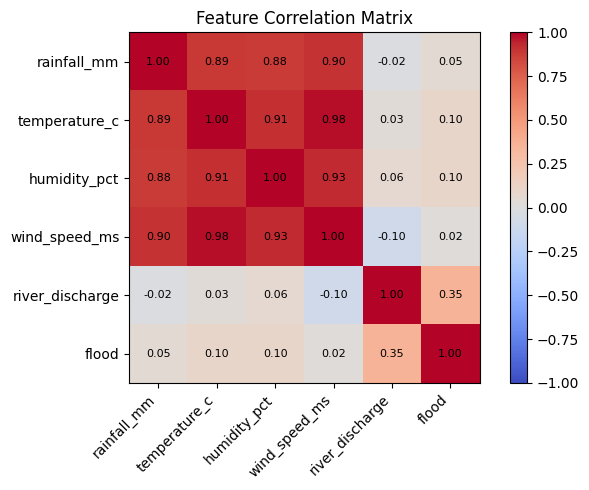

In [16]:
#  Correlation analysis

corr = df[["rainfall_mm", "temperature_c", "humidity_pct", "wind_speed_ms", "river_discharge", "flood"]].corr()
plt.figure(figsize=(7,5))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.xticks(range(len(corr)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr)), corr.columns)
plt.colorbar()
plt.title("Feature Correlation Matrix")
for i in range(len(corr)):
    for j in range(len(corr)):
        plt.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center", fontsize=8)
plt.tight_layout()
plt.show()


In [17]:
#  NDMA severity context


if "Total deaths" in ndma_df.columns and "Region" in ndma_df.columns:
    top_regions = ndma_df.sort_values("Total deaths", ascending=False).head(10)
    fig = px.bar(top_regions, x="Region", y="Total deaths", title="2022 Floods: Deaths by Region (NDMA data)")
    fig.show()

print("Total deaths across all regions (2022 event):", ndma_df["Total deaths"].sum() if "Total deaths" in ndma_df.columns else "column not found — check ndma_df.columns")


Total deaths across all regions (2022 event): 1545


In [18]:
#  Lag & rolling rainfall features

for lag in [1, 3, 7]:
    df[f"rainfall_lag_{lag}"] = df["rainfall_mm"].shift(lag)

for window in [3, 7, 14]:
    df[f"rainfall_roll_sum_{window}"] = df["rainfall_mm"].rolling(window).sum()

df["rainfall_intensity"] = df["rainfall_mm"] / (df["rainfall_mm"].rolling(7).mean() + 1e-6)
df["consecutive_rainy_days"] = (df["rainfall_mm"] > 1).astype(int).groupby(
    (df["rainfall_mm"] <= 1).cumsum()
).cumsum()


In [19]:
# River discharge change features

df["discharge_change_1d"] = df["river_discharge"].diff(1)
df["discharge_change_3d"] = df["river_discharge"].diff(3)
df["discharge_roll_mean_7"] = df["river_discharge"].rolling(7).mean()


In [20]:
#  Cyclical month encoding

df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)


In [21]:
#  flood within the next FORECAST_HORIZON_DAYS

df["target"] = df["flood"].shift(-1).rolling(FORECAST_HORIZON_DAYS, min_periods=1).max().shift(-(FORECAST_HORIZON_DAYS-1))
df["target"] = df["target"].fillna(0).astype(int)

feature_cols = [c for c in df.columns if c not in ["date", "flood", "target", "month"]]
df_model = df.dropna(subset=feature_cols).reset_index(drop=True)

print(df_model.shape)
print(df_model["target"].value_counts())


(2384, 22)
target
0    1804
1     580
Name: count, dtype: int64


In [22]:
#  Time-based train/test split

split_date = df_model["date"].quantile(0.8)
train_df = df_model[df_model["date"] <= split_date]
test_df = df_model[df_model["date"] > split_date]

X_cols = feature_cols
X_train, y_train = train_df[X_cols], train_df["target"]
X_test, y_test = test_df[X_cols], test_df["target"]

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train flood rate: {y_train.mean():.3f} | Test flood rate: {y_test.mean():.3f}")


Train: (1907, 18), Test: (477, 18)
Train flood rate: 0.239 | Test flood rate: 0.260


In [23]:
#  Evaluation helper

def evaluate(y_true, y_pred, y_prob, name):
    print(f"--- {name} ---")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.3f}")
    print(f"Precision: {precision_score(y_true, y_pred, zero_division=0):.3f}")
    print(f"Recall:    {recall_score(y_true, y_pred, zero_division=0):.3f}")
    print(f"F1:        {f1_score(y_true, y_pred, zero_division=0):.3f}")
    if len(set(y_true)) > 1:
        print(f"ROC-AUC:   {roc_auc_score(y_true, y_prob):.3f}")
    print(confusion_matrix(y_true, y_pred))
    print()

# Random Forest
rf_model = RandomForestClassifier(n_estimators=300, max_depth=8, class_weight="balanced", random_state=42)
rf_model.fit(X_train, y_train)
evaluate(y_test, rf_model.predict(X_test), rf_model.predict_proba(X_test)[:,1], "Random Forest")


--- Random Forest ---
Accuracy:  0.662
Precision: 0.423
Recall:    0.823
F1:        0.559
ROC-AUC:   0.817
[[214 139]
 [ 22 102]]



In [27]:
# XGBoost

scale_pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
xgb_model = xgb.XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    scale_pos_weight=scale_pos_weight, eval_metric="logloss", random_state=42
)
xgb_model.fit(X_train, y_train)
evaluate(y_test, xgb_model.predict(X_test), xgb_model.predict_proba(X_test)[:,1], "XGBoost")


--- XGBoost ---
Accuracy:  0.755
Precision: 0.521
Recall:    0.702
F1:        0.598
ROC-AUC:   0.804
[[273  80]
 [ 37  87]]



In [31]:
#  LightGBM (kept for comparison)

lgb_model = lgb.LGBMClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    class_weight="balanced", random_state=42
)
lgb_model.fit(X_train, y_train)
evaluate(y_test, lgb_model.predict(X_test), lgb_model.predict_proba(X_test)[:,1], "LightGBM")



df["discharge_change_7d"] = df["river_discharge"].diff(7)
df["discharge_roll_max_7"] = df["river_discharge"].rolling(7).max()
df["discharge_roll_max_14"] = df["river_discharge"].rolling(14).max()
df["rainfall_roll_sum_21"] = df["rainfall_mm"].rolling(21).sum()

feature_cols = [c for c in df.columns if c not in ["date", "flood", "target", "month"]]
df_model = df.dropna(subset=feature_cols).reset_index(drop=True)

split_date = df_model["date"].quantile(0.8)
train_df = df_model[df_model["date"] <= split_date]
test_df = df_model[df_model["date"] > split_date]

X_cols = feature_cols
X_train, y_train = train_df[X_cols], train_df["target"]
X_test, y_test = test_df[X_cols], test_df["target"]

scale_pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)


from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import fbeta_score, make_scorer

f2_scorer = make_scorer(fbeta_score, beta=2)

param_grid = {
    "max_depth": [4, 6, 8, 10],
    "learning_rate": [0.01, 0.05, 0.1],
    "n_estimators": [200, 300, 500],
    "min_child_weight": [1, 3, 5],
    "subsample": [0.7, 0.85, 1.0]
}

search = RandomizedSearchCV(
    xgb.XGBClassifier(scale_pos_weight=scale_pos_weight, eval_metric="logloss", random_state=42),
    param_distributions=param_grid,
    n_iter=50,
    scoring=f2_scorer,
    cv=3,
    random_state=42
)
search.fit(X_train, y_train)

print("Best params:", search.best_params_)
best_xgb = search.best_estimator_
xgb_probs = best_xgb.predict_proba(X_test)[:, 1]

# 3. Threshold tuning on the F2-tuned model
for threshold in [0.5, 0.4, 0.35, 0.3, 0.25]:
    preds = (xgb_probs > threshold).astype(int)
    print(f"\n--- Threshold {threshold} ---")
    evaluate(y_test, preds, xgb_probs, f"XGBoost F2-tuned (threshold={threshold})")

[LightGBM] [Info] Number of positive: 456, number of negative: 1445
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001098 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4824
[LightGBM] [Info] Number of data points in the train set: 1901, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

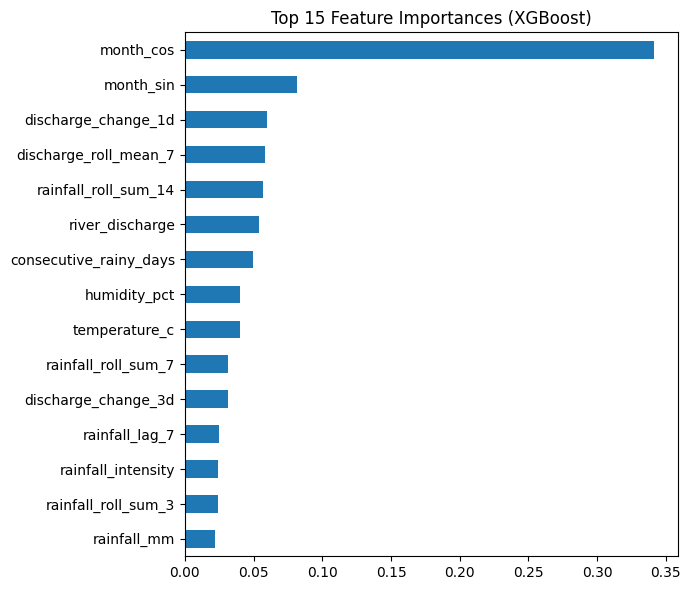

In [26]:
# Feature importance sanity check

importances = pd.Series(xgb_model.feature_importances_, index=X_cols).sort_values(ascending=False)
importances.head(15).plot(kind="barh", figsize=(7,6), title="Top 15 Feature Importances (XGBoost)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [32]:
import joblib


FINAL_THRESHOLD = 0.25

model_package = {
    "model": best_xgb,
    "threshold": FINAL_THRESHOLD,
    "feature_columns": X_cols,
    "forecast_horizon_days": FORECAST_HORIZON_DAYS,
    "location": {"latitude": LATITUDE, "longitude": LONGITUDE}
}

joblib.dump(model_package, "flood_model_final.pkl")
print("Saved model_package to flood_model_final.pkl")


from google.colab import files
files.download("flood_model_final.pkl")

Saved model_package to flood_model_final.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>